# Stage 2 - Clustering for diversity

Separate embeddings into clusters -> group 'similar' images together. The query selection chooses the most typical point in each cluster -> multiple points are not taken from the same cluster, as this would be 'redundant' -> eat into the budget unnecessarily.

NB: the latter stages of the TypiClust -> TCP_RP algorithm will use the model + the embeddings it learnt in stage 1. Ensure you've run the first notebook ->  saved the embeddings and model before you run this notebook.

# Step 1: Set up

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors
import numpy as np

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Step 2: Define clustering algorithm

In [4]:
def kmeans_cluster(embeddings, K):
    """
    embeddings: numpy array of shape (N, 512)
    K: number of clusters = min(|L_prev| + B, max_clusters)
    returns: cluster assignment (labels -> indices) for each of the N points
    """
    # Paper uses KMeans for K<=50, MiniBatchKMeans otherwise (Appendix F.1)
    if K <= 50:
        kmeans = KMeans(n_clusters=K, random_state=42)
    else:
        kmeans = MiniBatchKMeans(n_clusters=K, random_state=42)

    cluster_assignments = kmeans.fit_predict(embeddings)  # (N,) array
    return cluster_assignments

# Stage 3 - Querying for typicality + diversity

# Step 1: define typicality function

> To capture the principle of max density, we define the Typicality of an example by its density in some semantically meaningful feature space. Formally, we measure an example’s Typicality by the inverse of the average Euclidean distance to its K* nearest neighbours, namely:
>
> $$\text{Typicality}(x) = \left(\frac{1}{K}\sum_{x_i \in \text{K-NN}(x)} \|x - x_i\|_2\right)^{-1}$$

*K = 20 was used in the paper, so it will be used in this notebook. However, the paper notes that the value of K is not that important.

In [5]:
def Typicality(cluster_embeddings, K=20):
    """
    cluster_embeddings: (M, 512) array of embeddings for points in ONE cluster
    K: number of nearest neighbours, paper uses K=20
    returns: (M,) array of typicality scores, one per point
    """

    # Fit KNN on the cluster embeddings
    # K+1 because each point is its own nearest neighbour
    k = min(K + 1, len(cluster_embeddings))
    neighbours = NearestNeighbors(n_neighbors=k).fit(cluster_embeddings)
    distances, _ = neighbours.kneighbors(cluster_embeddings)

    # distances[:, 0] is always 0 (self), so skip it
    avg_distances = distances[:, 1:].mean(axis=1)  # (M,)

    typicality = 1.0 / (avg_distances + 1e-8) # prevent divion by zero error
    return typicality

# Step 2: define query selection algorithm

In [6]:
def query_selection(embeddings, cluster_assignments, labelled_indices, B):
    """
    embeddings:          (N, 512) numpy array - all 50k embeddings
    cluster_assignments: (N,) numpy array - cluster id for each image
    labelled_indices:    list of ints - indices of images already labelled
    B:                   int - how many new points to query this round (budget)

    returns: list of B indices to query
    """
    # 1. Find uncovered clusters
    covered = set(cluster_assignments[i] for i in labelled_indices)
    K = cluster_assignments.max() + 1  # total number of clusters
    uncovered = [c for c in range(K) if c not in covered]

    # 2. Sort uncovered by cluster size, take B largest (ignore clusters with fewer than 5 points)
    cluster_sizes = {c: np.sum(cluster_assignments == c) for c in uncovered}
    valid_uncovered = [c for c in uncovered if cluster_sizes[c] >= 5]
    largest_B = sorted(valid_uncovered, key=lambda c: -cluster_sizes[c])[:B]

    # 3. For each selected cluster, pick most typical point
    queries = []
    for cluster_id in largest_B:
        cluster_indices = np.where(cluster_assignments == cluster_id)[0] # indices of images in this cluster
        cluster_embs = embeddings[cluster_indices] # embeddings of the images in this cluster

        K_neighbours = min(20, len(cluster_embs))
        typicality_scores = Typicality(cluster_embs, K=K_neighbours) # array of all typicality scores of the embeddings in this cluster
        best_local = np.argmax(typicality_scores) # best typicality scores (indexed locally i.e. indices of typicality scores == cluster_indices == cluster_embs)
        best_global = cluster_indices[best_local] # get global/actual index of image
        queries.append(best_global)

    return queries

# TCP_RP Final Implementation

NB: the latter stages of the TypiClust -> TCP_RP algorithm will use the model + the embeddings it learnt in stage 1. Ensure you've run the first notebook ->  saved the embeddings and model before you run this section.

# Step 1: Set up

In [8]:
## SimCLR model def
# First load the ResNet-18 classifier
resnet18 = torchvision.models.resnet18(weights=None, progress=True)

# Reduce kernel size and stride as CIFAR10 images are very small
resnet18.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)

# Remove max pooling layer for same reason
resnet18.maxpool = nn.Identity()

# Remove final classification layer (as embeddings are in penultimate layer)
resnet18.fc = nn.Identity()

# Define projection head (only used during training)
class ProjectionHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(512, 512)
        self.bn = nn.BatchNorm1d(512)
        self.relu = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(512, 128)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.fc2(x)
        return F.normalize(x, dim=1)

# Define SimCLR model (a wrapper of the ResNet-18 and projection head)
class SimCLR(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = resnet18
        self.projection = ProjectionHead()

    def forward(self, x1, x2):
        h1 = self.encoder(x1)  # (batch_size, 512)
        h2 = self.encoder(x2)  # (batch_size, 512)

        z1 = self.projection(h1)  # (batch_size, 128)
        z2 = self.projection(h2)  # (batch_size, 128)

        return z1, z2

    # Use after training for embedding extraction
    def get_embedding(self, x):
        return self.encoder(x)

In [9]:
# Load saved model
checkpoint_path_simclr = '/content/drive/MyDrive/5CCSAMLF_CW2/models/simclr_latest.pth'
checkpoint_simclr = torch.load(checkpoint_path_simclr)

simclr = SimCLR().to(device)
simclr.load_state_dict(checkpoint_simclr['model_state_dict'])

<All keys matched successfully>

In [10]:
# Load saved train embeddings + labels
checkpoint_path_train = '/content/drive/MyDrive/5CCSAMLF_CW2/models/train_embeddings.pth'
checkpoint_train = torch.load(checkpoint_path_train)

train_embeddings = checkpoint_train['embeddings']
train_labels = checkpoint_train['labels']

In [11]:
# Load saved test embeddings + labels
checkpoint_path_test = '/content/drive/MyDrive/5CCSAMLF_CW2/models/test_embeddings.pth'
checkpoint_test = torch.load(checkpoint_path_test)

test_embeddings = checkpoint_test['embeddings']
test_labels = checkpoint_test['labels']

In [12]:
# Define train/evaluation loop to evaluate TCP_RP AL strategy
def train_and_evaluate(labelled_indices, num_epochs=200):
    """
    Train a linear classifier on the labelled embeddings, evaluate on CIFAR-10 test set.
    Paper uses a linear layer trained on the frozen SimCLR embedding (Section 4.2.2).
    """
    X_train = train_embeddings[labelled_indices].to(device)
    y_train = train_labels[labelled_indices].to(device)

    X_test = test_embeddings.to(device)
    y_test = test_labels.to(device)

    # Instantiate a linear classifier: d = 512 -> C = 10 (classes)
    linear = nn.Linear(512, 10).to(device) # d x C (F.2.2.)

    # Paper uses SGD, lr=2.5, cosine scheduler, 2x epochs vs. fully supervised
    optimiser = torch.optim.SGD(linear.parameters(), lr=2.5,
                                momentum=0.9, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=num_epochs)
    criterion = nn.CrossEntropyLoss()

    # 4. Train
    linear.train()
    for epoch in range(num_epochs):
        optimiser.zero_grad()
        outputs = linear(X_train)       # (|L|, 10)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimiser.step()
        scheduler.step()

    # Evaluate on test set
    linear.eval()
    with torch.no_grad():
        test_outputs = linear(X_test)
        preds = test_outputs.argmax(dim=1)
        acc = (preds == y_test).float().mean().item() * 100
    return acc

# Step 2: Implementation (AL loop)

In [16]:
'''
For each iteration, new labels are selected to be queried, then a linear classifier is
trained on those labels and evaluated.
'''

budgets = []
accuracies_typiclust = []
accuracies_random = []

labelled_indices = []
random_indices = []
B = 10

train_embeddings_np = train_embeddings.numpy()

# TODO: compute other baselines as seen in paper? (uncertainty, entropy, margin, coreset, DBAL, BALD, BADGE, (random, TPC_RP))
for iteration in range(6):
    K = min(len(labelled_indices) + B, 500)
    cluster_assignments = kmeans_cluster(train_embeddings_np, K)
    new_queries = query_selection(train_embeddings_np, cluster_assignments,
                                  labelled_indices, B)
    labelled_indices.extend([int(q) for q in new_queries])

    # Random baseline - same budget, random selection
    all_indices = list(range(len(train_labels)))
    available = [i for i in all_indices if i not in random_indices]
    random_indices.extend(np.random.choice(available, B, replace=False).tolist())

    # Get accuracies
    acc_typi = train_and_evaluate(labelled_indices)
    acc_rand = train_and_evaluate(random_indices)

    budgets.append(len(labelled_indices))
    accuracies_typiclust.append(acc_typi)
    accuracies_random.append(acc_rand)

    print(f"Iteration {iteration+1} | Budget {len(labelled_indices)} | "
          f"TPC_RP: {acc_typi:.1f} % | Random: {acc_rand:.1f} %")

Iteration 1 | Budget 10 | TPC_RP: 29.8% | Random: 39.7 %
Iteration 2 | Budget 20 | TPC_RP: 54.4% | Random: 55.4 %
Iteration 3 | Budget 30 | TPC_RP: 72.4% | Random: 63.8 %
Iteration 4 | Budget 40 | TPC_RP: 73.4% | Random: 70.9 %
Iteration 5 | Budget 50 | TPC_RP: 79.9% | Random: 76.0 %
Iteration 6 | Budget 60 | TPC_RP: 81.1% | Random: 78.0 %


# Step 3: Visualise results

In [14]:
import matplotlib.pyplot as plt
import numpy as np

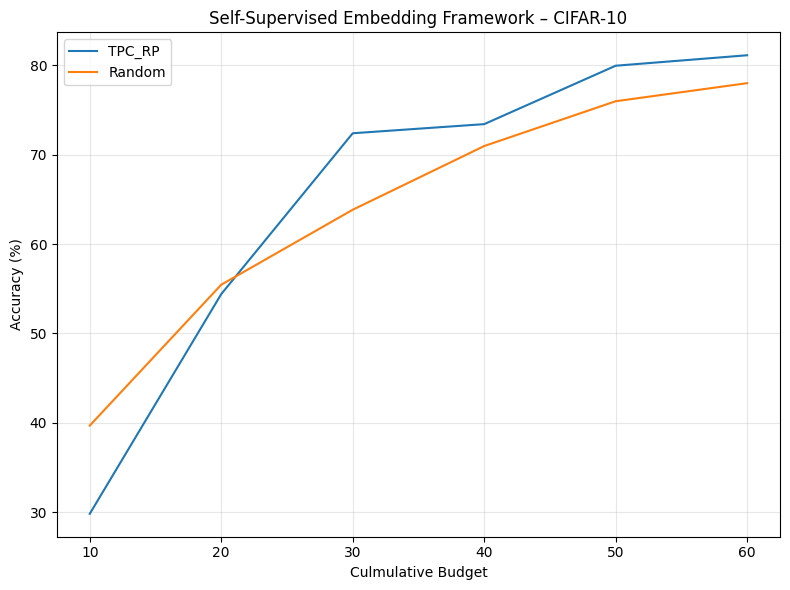

In [23]:
x = budgets
y1 = accuracies_typiclust
y2 = accuracies_random

# Plot graph

plt.figure(figsize=(8, 6))
plt.plot(x, y1, label = 'TPC_RP')
plt.plot(x, y2, label = 'Random')
plt.ylabel('Accuracy (%)')
plt.xlabel('Culmulative Budget')
plt.title('Self-Supervised Embedding Framework – CIFAR-10')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend()

# Save results to use in report
plt.savefig('results.png', format='png')
plt.savefig('results.svg', format='svg')

plt.show()

In [ ]:
## Next steps
# Start and work on report for an hour or so
# Task 3
# Add Uncertainty and Margin baselines to AL loop
# Train new model <- run updated notebook 1 (overnight)
# Get results <- run updated notebook 2

## EXTENSION:
# Write train_and_evaluate methods for the fully supervised framework (i.e. training a ResNet18 from scratch using labelled queries)
# --> NB: don't even try to implement the semi-supervised framework - not enough time to learn about and wrestle with FlexMatch